In [1]:
# 1) Core imports and configuration

import os
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

# Ablation Output Directory ---
SAVE_DIR = "results/ablation1"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Results will be saved to: {SAVE_DIR}")
# ------------------------------------------

# EdgeSimPy — correct import pattern
try:
    from edge_sim_py import *
    import edge_sim_py as EDGESIMPY_MODULE
    # Verify Simulator is actually available after wildcard import
    if "Simulator" not in dir():
        raise ImportError("Simulator class not found after edge_sim_py wildcard import.")
    print(f"EdgeSimPy available: {EDGESIMPY_MODULE.__version__ if hasattr(EDGESIMPY_MODULE, '__version__') else 'version unknown'}")
except ImportError as e:
    raise ImportError(
        "EdgeSimPy is not installed or not visible in this environment.\n"
        "Run:  pip install git+https://github.com/EdgeSimPy/EdgeSimPy.git\n"
        "Then restart the kernel."
    ) from e

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print(f"PyTorch:    {torch.__version__}")
print(f"Gymnasium:  {gym.__version__}")
print(f"Device:     {DEVICE}")

Results will be saved to: results/ablation1
EdgeSimPy available: 1.1.0
PyTorch:    2.10.0+cpu
Gymnasium:  1.2.3
Device:     cpu


In [2]:
# 2) Global configuration and infrastructure spec

@dataclass(frozen=True)
class GlobalConfig:
    # Infrastructure
    EDGE_SERVER_COUNT: int = 10
    CLOUD_SERVER_COUNT: int = 1
    EDGE_CPU_MIPS: float = 2000.0
    CLOUD_CPU_MIPS: float = 25000.0
    EDGE_CLOUD_BANDWIDTH_MBPS: float = 100.0

    # Task model
    TASK_SIZE_MB: float = 0.5
    TASK_COMPLEXITY_GIGACYCLES: float = 1.0

    # Paths
    RESULTS_DIR: str = SAVE_DIR
    SCENARIO_FILE: str = f"results/edgesimpy/ablation1.json"

    # RL defaults
    GAMMA: float = 0.99
    ACTOR_LR: float = 1e-4
    CRITIC_LR: float = 1e-4
    BATCH_SIZE: int = 64
    MEMORY_CAPACITY: int = 50_000

    # Experiment seeds
    SEEDS: Tuple[int, ...] = (10, 20, 30, 40, 50)

CONFIG = GlobalConfig()

# Expose seeds as a list for loops
EXPERIMENT_SEEDS = list(CONFIG.SEEDS)

Path(CONFIG.RESULTS_DIR).mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class InfrastructureSpec:
    edge_server_count: int          = CONFIG.EDGE_SERVER_COUNT
    cloud_server_count: int         = CONFIG.CLOUD_SERVER_COUNT
    edge_cpu_mips: float            = CONFIG.EDGE_CPU_MIPS
    cloud_cpu_mips: float           = CONFIG.CLOUD_CPU_MIPS
    edge_cloud_bandwidth_mbps: float = CONFIG.EDGE_CLOUD_BANDWIDTH_MBPS
    task_size_mb: float             = CONFIG.TASK_SIZE_MB
    task_complexity_gigacycles: float = CONFIG.TASK_COMPLEXITY_GIGACYCLES
    dataset_dir: str                = CONFIG.RESULTS_DIR
    dataset_file: str               = CONFIG.SCENARIO_FILE

INFRA = InfrastructureSpec()
print("Config and infrastructure spec ready.")
print(f"Results Directory: {CONFIG.RESULTS_DIR}")
print(f"Seeds: {EXPERIMENT_SEEDS}")
print(f"Device: {DEVICE}")

Config and infrastructure spec ready.
Results Directory: results/ablation1
Seeds: [10, 20, 30, 40, 50]
Device: cpu


In [3]:
# 3) Build and save EdgeSimPy scenario JSON (infrastructure only)

def build_edgesimpy_dataset(spec: InfrastructureSpec) -> Dict[str, Any]:
    edge_servers = [
        {
            "attributes": {
                "id": i + 1,
                "model_name": f"edge_{i + 1}",
                "cpu": spec.edge_cpu_mips,
            },
            "relationships": {},
        }
        for i in range(spec.edge_server_count)
    ]

    cloud_servers = [
        {
            "attributes": {
                "id": 10_000 + i + 1,
                "model_name": f"cloud_{i + 1}",
                "cpu": spec.cloud_cpu_mips,
            },
            "relationships": {},
        }
        for i in range(spec.cloud_server_count)
    ]

    dataset = {
        "metadata": {
            "edge_server_count": spec.edge_server_count,
            "cloud_server_count": spec.cloud_server_count,
            "edge_cloud_bandwidth_mbps": spec.edge_cloud_bandwidth_mbps,
            "task_size_mb": spec.task_size_mb,
            "task_complexity_gigacycles": spec.task_complexity_gigacycles,
        },
        "edge_servers": edge_servers,
        "cloud_servers": cloud_servers,
    }

    return dataset


EDGE_DATASET = build_edgesimpy_dataset(INFRA)

with open(INFRA.dataset_file, "w", encoding="utf-8") as f:
    json.dump(EDGE_DATASET, f, indent=2)

print(f"EdgeSimPy scenario written to: {INFRA.dataset_file}")
print(f"Edge servers: {INFRA.edge_server_count}, cloud servers: {INFRA.cloud_server_count}")

EdgeSimPy scenario written to: results/edgesimpy/ablation1.json
Edge servers: 10, cloud servers: 1


In [4]:
# 4) EdgeSimPy–Gymnasium environment wrapper (scheduling env)

class EdgeSimPySchedulingEnv(gym.Env):
    """Binary edge/cloud scheduling environment backed by EdgeSimPy.
    
    State space (5D):
        [queue_avg, workload_norm, pressure_norm, lat_weight, energy_cost_norm]
        - queue_avg       : current queue backlog (0–300)
        - workload_norm   : normalised task arrival rate (0–1)
        - pressure_norm   : load above baseline, normalised (0–1)
        - lat_weight      : current latency objective weight from DynamicWeightController (0–1)
        - energy_cost_norm: last-step energy cost, normalised (0–1)
    """

    metadata = {"render_modes": ["human"], "render_fps": 1}

    def __init__(
        self,
        scenario_config=None,
        spec: InfrastructureSpec = INFRA,
        scenario_file: Optional[str] = None,
        render_mode: Optional[str] = None,
    ):
        super().__init__()

        self.spec = spec
        self.scenario_config = scenario_config
        self.scenario_file = scenario_file or getattr(CONFIG, "EDGESIMPY_SCENARIO_FILE", None)
        self.render_mode = render_mode

        # RL interface
        self.action_space = spaces.Discrete(2)          # 0 = edge, 1 = cloud
        self.observation_space = spaces.Box(            # 5D
            low=np.array( [0.0,   0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([300.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        # Internal state
        self.simulator: Optional[Simulator] = None
        self.pending_action: int   = 0
        self.episodelength: int    = 2000
        self.stepcount: int        = 0
        self.currentworkload: int  = 50
        self.queueavg: float       = 10.0
        self.last_latency_s: float = 0.0
        self.last_energy_j: float  = 0.0
        self.current_lat_weight: float = 0.3   # ← NEW: updated externally by DynamicWeightController

    # ── Weight interface ──────────────────────────────────────────────────────

    def update_weights(self, lat_weight: float, eng_weight: float) -> None:  # ← NEW
        """Called by DynamicWeightController after each weight update.
        Exposes current objective priority to the agent's policy network.
        Required per Abels et al. (2019) §3 for weight-conditioned policy learning.
        """
        self.current_lat_weight = float(np.clip(lat_weight, 0.0, 1.0))

    # ── EdgeSimPy integration helpers ─────────────────────────────────────────

    def _build_simulator(self) -> Optional[Simulator]:
        if self.scenario_file is None or not os.path.exists(self.scenario_file):
            return None
        try:
            sim = Simulator(
                tick_duration=1,
                tick_unit="seconds",
                resource_management_algorithm=self._resource_management_algorithm,
            )
            try:
                sim.initialize(input_file=self.scenario_file)
            except TypeError:
                sim.initialize(self.scenario_file)
            return sim
        except Exception:
            return None

    def _resource_management_algorithm(self, parameters=None):
        if parameters is None:
            parameters = {}

        action      = int(parameters.get("action", self.pending_action))
        target_tier = "edge" if action == 0 else "cloud"

        EdgeServer = getattr(EDGESIMPY_MODULE, "EdgeServer", None)
        Service    = getattr(EDGESIMPY_MODULE, "Service",    None)

        if EdgeServer is None or Service is None:
            return {"action": action, "target_tier": target_tier, "placements": 0}

        try:
            servers  = list(EdgeServer.all())
            services = list(Service.all())
        except Exception:
            return {"action": action, "target_tier": target_tier, "placements": 0}

        def is_tier(server, tier: str) -> bool:
            name = str(getattr(server, "model_name", "")).lower()
            if tier == "cloud":
                return "cloud" in name or int(getattr(server, "id", 0)) >= 10_000
            return "edge" in name or int(getattr(server, "id", 0)) < 10_000

        def free_cpu(server) -> float:
            total = float(getattr(server, "cpu", 0.0))
            used  = float(getattr(server, "cpu_demand",
                          getattr(server, "cpu_used", 0.0)))
            return total - used

        candidates = sorted(
            [s for s in servers if is_tier(s, target_tier)],
            key=free_cpu, reverse=True,
        )

        placements = 0
        for svc in services:
            if getattr(svc, "server", None) is not None:
                continue
            if bool(getattr(svc, "finished", False)):
                continue
            for srv in candidates:
                fn = getattr(srv, "provision", None)
                if callable(fn):
                    try:
                        fn(service=svc)
                    except TypeError:
                        try:
                            fn(svc)
                        except Exception:
                            continue
                    placements += 1
                    break

        return {"action": action, "target_tier": target_tier, "placements": placements}

    def _advance_simulator_one_tick(self) -> None:
        if self.simulator is None:
            return
        if hasattr(self.simulator, "step") and callable(self.simulator.step):
            self.simulator.step()
        elif hasattr(self.simulator, "run_step") and callable(self.simulator.run_step):
            self.simulator.run_step()

    def _get_workload(self, timestep: int) -> int:
        if self.scenario_config is None:
            return int(self.currentworkload)
        if hasattr(self.scenario_config, "workload_at"):
            return int(self.scenario_config.workload_at(timestep))
        raise AttributeError("ScenarioConfig must define workload_at()")

    # ── Analytical latency / energy model ────────────────────────────────────

    def _compute_metrics(self, action: int) -> Tuple[float, float]:
        edge_total_mips  = self.spec.edge_server_count  * self.spec.edge_cpu_mips
        cloud_total_mips = self.spec.cloud_server_count * self.spec.cloud_cpu_mips
        cycles           = self.spec.task_complexity_gigacycles * 1e9

        edge_compute_base_s  = cycles / (edge_total_mips  * 1e6)
        cloud_compute_base_s = cycles / (cloud_total_mips * 1e6)
        transmission_base_s  = (self.spec.task_size_mb * 8.0) / self.spec.edge_cloud_bandwidth_mbps

        edge_latency_s = edge_compute_base_s * (
            1.0 + self.queueavg / 80.0 + self.currentworkload / 250.0
        )
        cloud_latency_s = (transmission_base_s + cloud_compute_base_s) * (
            1.0 + self.queueavg / 220.0 + self.currentworkload / 400.0
        )

        edge_energy_j  = 1.6 * edge_latency_s  + 0.002  * self.currentworkload
        cloud_energy_j = 0.8 * cloud_latency_s + 0.0008 * self.currentworkload

        if int(action) == 0:
            return float(edge_latency_s), float(edge_energy_j)
        return float(cloud_latency_s), float(cloud_energy_j)

    def _build_state(self) -> np.ndarray:                              # ← CHANGED
        workload_norm    = min(float(self.currentworkload) / 150.0, 1.0)
        pressure_norm    = min(max((float(self.currentworkload) - 50.0) / 100.0, 0.0), 1.0)
        energy_cost_norm = min(float(self.last_energy_j) / 5.0, 1.0)  # ceiling 5J [ASSUMED]
        return np.array(
            [float(self.queueavg), workload_norm, pressure_norm,
             self.current_lat_weight, energy_cost_norm],
            dtype=np.float32,
        )

    # ── Gymnasium API ─────────────────────────────────────────────────────────

    def reset(
        self,
        *,
        seed: Optional[int] = None,
        options: Optional[Dict[str, Any]] = None,
        episodelength: Optional[int] = None,
        initialworkload: Optional[int] = None,
    ):
        super().reset(seed=seed)
        if seed is not None:
            set_global_seed(seed)

        options = options or {}
        self.episodelength = int(
            episodelength if episodelength is not None
            else options.get("episodelength", self.episodelength)
        )
        self.currentworkload = int(
            initialworkload if initialworkload is not None
            else options.get("initialworkload", 50)
        )

        self.stepcount          = 0
        self.queueavg           = 10.0 + 0.10 * max(0, self.currentworkload - 50)
        self.last_latency_s     = 0.0
        self.last_energy_j      = 0.0
        self.pending_action     = 0
        self.current_lat_weight = 0.3   # ← NEW: reset to initial prior

        self.simulator = self._build_simulator()

        obs  = self._build_state()
        info = {
            "queueavg":         float(self.queueavg),
            "workloadlevel":    int(self.currentworkload),
            "selectedlatencys": float(self.last_latency_s),
            "selectedenergyj":  float(self.last_energy_j),
            "latencyreward":    float(-self.last_latency_s),
            "energyreward":     float(-self.last_energy_j),
        }
        return obs, info

    def step(self, action: int, workloadlevel: Optional[int] = None):
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action: {action}")

        self.pending_action = action

        if workloadlevel is not None:
            self.currentworkload = int(workloadlevel)
        else:
            self.currentworkload = self._get_workload(self.stepcount)

        offload_relief = 6.0 if action == 1 else 0.0
        queue_next = (
            0.90 * self.queueavg
            + 0.18 * self.currentworkload
            - 8.0
            - offload_relief
        )
        self.queueavg = float(np.clip(queue_next, 0.0, 300.0))

        self.last_latency_s, self.last_energy_j = self._compute_metrics(action)

        latency_reward = -float(self.last_latency_s)
        energy_reward  = -float(self.last_energy_j)
        scalar_reward  = 0.5 * latency_reward + 0.5 * energy_reward

        scheduling_info = self._resource_management_algorithm(
            parameters={"action": self.pending_action}
        )
        self._advance_simulator_one_tick()

        self.stepcount += 1
        terminated = False
        truncated  = self.stepcount >= self.episodelength

        obs  = self._build_state()
        info = {
            "queueavg":         float(self.queueavg),
            "workloadlevel":    int(self.currentworkload),
            "selectedlatencys": float(self.last_latency_s),
            "selectedenergyj":  float(self.last_energy_j),
            "latencyreward":    float(latency_reward),
            "energyreward":     float(energy_reward),
            "placements":       int(scheduling_info.get("placements", 0)),
            "targettier":       scheduling_info.get("target_tier", "edge"),
        }

        return obs, float(scalar_reward), terminated, truncated, info

    def render(self):
        if self.render_mode == "human":
            print(
                f"t={self.stepcount} "
                f"workload={self.currentworkload} "
                f"queue={self.queueavg:.2f} "
                f"latency={self.last_latency_s:.4f}s "
                f"energy={self.last_energy_j:.4f}J "
                f"lat_weight={self.current_lat_weight:.3f}"  # ← NEW: visible in render
            )

    def close(self):
        self.simulator = None

print("Environment wrapper ready:", EdgeSimPySchedulingEnv.__name__)

Environment wrapper ready: EdgeSimPySchedulingEnv


In [5]:
# 5) Actor–Critic neural architecture for MOPER

@dataclass(frozen=True)
class ActorCriticHyperParams:
    actor_learning_rate: float = CONFIG.ACTOR_LR
    critic_learning_rate: float = CONFIG.CRITIC_LR
    gamma: float = CONFIG.GAMMA
    batch_size: int = CONFIG.BATCH_SIZE
    memory_capacity: int = CONFIG.MEMORY_CAPACITY


class MOPERActorCriticNet(nn.Module):
    """
    Shared state encoder, one policy head, two value heads:
    - latency value
    - energy value
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(hidden_dim, action_dim)
        self.latency_value_head = nn.Linear(hidden_dim, 1)
        self.energy_value_head = nn.Linear(hidden_dim, 1)

    def forward(self, state: torch.Tensor):
        z = self.shared(state)
        logits = self.actor_head(z)
        latency_value = self.latency_value_head(z)
        energy_value = self.energy_value_head(z)
        return logits, latency_value, energy_value

    def action_distribution(self, state: torch.Tensor):
        logits, _, _ = self.forward(state)
        return torch.distributions.Categorical(logits=logits)

In [6]:
# 6) Dynamic weight adjustment mechanism

@dataclass(frozen=True)
class WeightControlConfig:
    high_load_threshold: float = 20.0
    low_load_latency_weight: float = 0.30
    high_load_latency_weight: float = 0.80
    adaptation_rate: float = 0.12
    ema_decay: float = 0.96
    ratio_blend: float = 0.15        # pull toward cost-proportional target
    queue_fallback_blend: float = 0.10
    min_latency_weight: float = 0.10
    max_latency_weight: float = 0.90
    
    # ← ADDED: Normalization constants to balance objective scales
    max_latency_cost: float = 0.5
    max_energy_cost: float = 5.0


class DynamicWeightController:
    """
    Maintains latency/energy weights using:
      1. EMA gap signal — reacts to sudden cost shifts (non-stationarity)
      2. Ratio signal  — steady-state pull toward cost-proportional weights
      3. Queue prior   — pressure-based override at high load
    """

    def __init__(self, config: WeightControlConfig = WeightControlConfig()):
        self.config = config
        self.alpha = float(config.low_load_latency_weight)
        self.beta  = 1.0 - self.alpha

        self.latency_ema: Optional[float] = None
        self.energy_ema:  Optional[float] = None
        self.eps = 1e-8

    def _queue_prior(self, current_queue_avg: float) -> float:
        if float(current_queue_avg) >= self.config.high_load_threshold:
            return float(self.config.high_load_latency_weight)
        return float(self.config.low_load_latency_weight)

    def _normalize(self, latency_weight: float) -> Tuple[float, float]:
        lw = float(np.clip(
            latency_weight,
            self.config.min_latency_weight,
            self.config.max_latency_weight,
        ))
        return lw, 1.0 - lw

    def update_from_feedback(
        self,
        latency_cost: float,
        energy_cost: float,
        current_queue_avg: float,
    ) -> Tuple[float, float]:
        
        # ← CHANGED: Normalize costs to 0.0-1.0 range so energy does not dominate latency
        lc_norm = min(float(max(latency_cost, self.eps)) / self.config.max_latency_cost, 1.0)
        ec_norm = min(float(max(energy_cost, self.eps)) / self.config.max_energy_cost, 1.0)

        # Update EMA using normalized costs
        if self.latency_ema is None:
            self.latency_ema = lc_norm
            self.energy_ema  = ec_norm
        else:
            d = self.config.ema_decay
            self.latency_ema = d * self.latency_ema + (1.0 - d) * lc_norm
            self.energy_ema  = d * self.energy_ema  + (1.0 - d) * ec_norm

        # Signal 1: EMA gap — fires when costs deviate from running average
        gap_latency = lc_norm - self.latency_ema
        gap_energy  = ec_norm - self.energy_ema

        self.alpha = self.alpha + self.config.adaptation_rate * (gap_latency - gap_energy)

        # Signal 2: ratio-based target — steady-state adaptation
        total       = self.latency_ema + self.energy_ema + self.eps
        ratio_alpha = self.latency_ema / total   # dynamic, updates every step

        self.alpha = (1.0 - self.config.ratio_blend) * self.alpha + \
                     self.config.ratio_blend * ratio_alpha

        # Signal 3: queue pressure prior
        queue_alpha = self._queue_prior(current_queue_avg)
        self.alpha = (1.0 - self.config.queue_fallback_blend) * self.alpha + \
                     self.config.queue_fallback_blend * queue_alpha

        self.alpha, self.beta = self._normalize(self.alpha)
        return self.alpha, self.beta

    def select_weights(self, current_queue_avg: float) -> Tuple[float, float]:
        """Passive weight selection without feedback — used for inference only."""
        queue_alpha = self._queue_prior(current_queue_avg)
        alpha = (1.0 - self.config.queue_fallback_blend) * self.alpha + \
                self.config.queue_fallback_blend * queue_alpha
        self.alpha, self.beta = self._normalize(alpha)
        return self.alpha, self.beta

print("DynamicWeightController ready.")

DynamicWeightController ready.


In [7]:
# 7) Uniform Experience Replay (Ablation Part 1 - No MOPER)

import random
from collections import deque
from dataclasses import dataclass
import numpy as np

@dataclass
class ObjectiveTransition:
    state: np.ndarray
    action: int
    latency_reward: float
    energy_reward: float
    scalar_reward: float
    next_state: np.ndarray
    done: bool
    latency_weight: float
    energy_weight: float

class UniformObjectiveReplayBuffer:
    """
    Ablation buffer: Stores per-objective rewards but samples uniformly.
    Completely lacks prioritization and the mismatch multiplier.
    """
    def __init__(self, capacity: int):
        if capacity <= 0:
            raise ValueError("capacity must be positive")
        self.capacity = int(capacity)
        self.memory = deque(maxlen=self.capacity)

    def __len__(self) -> int:
        return len(self.memory)

    def add(self, transition: ObjectiveTransition, priority: float = 1.0) -> None:
        # Priority argument is ignored to simulate the ablated memory
        self.memory.append(transition)

    def sample(self, batch_size: int):
        if batch_size > len(self.memory):
            raise ValueError("batch_size cannot exceed current buffer size")

        # Pure random uniform sampling (No prioritized replay)
        batch = random.sample(self.memory, batch_size)
        
        # Return dummy indices and is_weights to preserve agent code compatibility
        indices = np.zeros(batch_size, dtype=np.int64)
        is_weights = np.ones(batch_size, dtype=np.float32)

        return batch, indices, is_weights

    def update_priorities(self, indices, priorities) -> None:
        # Ablated: Does nothing
        pass

    def boost_all_priorities(self, factor: float = 2.0) -> None:
        # Ablated: Lacks the mismatch multiplier mechanism
        # This will cause the memory to remain poisoned during workload spikes
        pass

print("The ABLATED uniform memory buffer is ready.")

The ABLATED uniform memory buffer is ready.


In [8]:
# 8) Ablated Agent: MOPER without Prioritized Memory (Uniform Replay)

@dataclass(frozen=True)
class MOPERHyperParams:
    actor_lr: float = CONFIG.ACTOR_LR
    critic_lr: float = CONFIG.CRITIC_LR
    gamma: float = CONFIG.GAMMA
    batch_size: int = CONFIG.BATCH_SIZE
    memory_capacity: int = CONFIG.MEMORY_CAPACITY
    # PER parameters kept in struct for API compatibility, but heavily ignored by uniform buffer
    per_alpha: float = 0.6       
    per_beta: float = 0.4        
    per_eps: float = 1e-6        
    grad_clip_norm: float = 0.5

class AblatedMOPERActorCriticAgent:
    """
    ABLATION PART 1 AGENT:
    Actor:  policy logits (Categorical over edge/cloud)
    Critic: two separate value heads — latency and energy
    Replay: UniformObjectiveReplayBuffer (NO PRIORITIZATION)
    Weights: DynamicWeightController (DYNAMIC WEIGHTS ACTIVE)
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int = 2,
        hp: MOPERHyperParams = MOPERHyperParams(),
        seed: Optional[int] = None,
    ):
        if state_dim <= 0 or action_dim <= 0:
            raise ValueError("state_dim and action_dim must be positive")
        self.hp = hp
        self.device = DEVICE

        self.net = MOPERActorCriticNet(state_dim, action_dim).to(self.device)

        self.actor_optimizer = torch.optim.Adam(
            list(self.net.shared.parameters())
            + list(self.net.actor_head.parameters()),
            lr=hp.actor_lr,
        )
        self.critic_optimizer = torch.optim.Adam(
            list(self.net.shared.parameters())
            + list(self.net.latency_value_head.parameters())
            + list(self.net.energy_value_head.parameters()),
            lr=hp.critic_lr,
        )

        # <- CHANGED: Inject the crippled uniform buffer
        self.buffer = UniformObjectiveReplayBuffer(capacity=hp.memory_capacity)
        
        self.weight_controller = DynamicWeightController()
        self.latency_weight: float = self.weight_controller.alpha
        self.energy_weight: float = self.weight_controller.beta

        if seed is not None:
            set_global_seed(seed)

    # ── Public API ────────────────────────────────────────────────────────────

    def act(self, state: np.ndarray) -> int:
        state_t = torch.tensor(
            np.asarray(state, dtype=np.float32),
            dtype=torch.float32, device=self.device,
        ).unsqueeze(0)
        with torch.no_grad():
            dist = self.net.action_distribution(state_t)
        return int(dist.sample().item())

    def remember(
        self,
        state: np.ndarray,
        action: int,
        latency_reward: float,
        energy_reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        scalar_reward = (
            self.latency_weight * latency_reward
            + self.energy_weight * energy_reward
        )
        transition = ObjectiveTransition(
            state=np.asarray(state, dtype=np.float32),
            action=int(action),
            latency_reward=float(latency_reward),
            energy_reward=float(energy_reward),
            scalar_reward=float(scalar_reward),
            next_state=np.asarray(next_state, dtype=np.float32),
            done=bool(done),
            latency_weight=self.latency_weight,
            energy_weight=self.energy_weight,
        )
        # <- CHANGED: Removed self.buffer.max_priority() as Uniform Replay lacks it
        self.buffer.add(transition, priority=1.0)

    def update_weights(
        self, latency_cost: float, energy_cost: float, queue_avg: float,
        regime_change_threshold: float = 0.08,
        regime_boost_factor: float = 2.0
    ) -> Tuple[float, float]:
        old_alpha = self.latency_weight
        
        self.latency_weight, self.energy_weight = (
            self.weight_controller.update_from_feedback(
                latency_cost=latency_cost,
                energy_cost=energy_cost,
                current_queue_avg=queue_avg,
            )
        )
        
        delta_alpha = abs(self.latency_weight - old_alpha)
        if delta_alpha > regime_change_threshold and len(self.buffer) > 0:
            # This calls the empty dummy function in Uniform Replay, causing the replay bias crisis
            self.buffer.boost_all_priorities(factor=regime_boost_factor)
            
        return self.latency_weight, self.energy_weight

    def train_step(self) -> Dict[str, float]:
        if len(self.buffer) < self.hp.batch_size:
            return dict(updated=False, actor_loss=float("nan"),
                        critic_loss=float("nan"), td_error=float("nan"),
                        td_lat=float("nan"), td_eng=float("nan"),
                        replay_priority=float("nan"))

        batch, indices, is_weights = self.buffer.sample(self.hp.batch_size)

        states      = torch.tensor(np.array([t.state       for t in batch], dtype=np.float32), dtype=torch.float32, device=self.device)
        actions     = torch.tensor([t.action      for t in batch], dtype=torch.long,    device=self.device)
        lat_rewards = torch.tensor([t.latency_reward for t in batch], dtype=torch.float32, device=self.device)
        eng_rewards = torch.tensor([t.energy_reward  for t in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([t.next_state  for t in batch], dtype=np.float32), dtype=torch.float32, device=self.device)
        dones       = torch.tensor([float(t.done)    for t in batch], dtype=torch.float32, device=self.device)
        stored_lw   = torch.tensor([t.latency_weight for t in batch], dtype=torch.float32, device=self.device)
        stored_ew   = torch.tensor([t.energy_weight  for t in batch], dtype=torch.float32, device=self.device)
        isw         = torch.tensor(is_weights, dtype=torch.float32, device=self.device)

        logits, lat_vals, eng_vals = self.net(states)
        lat_vals = lat_vals.squeeze(-1)
        eng_vals = eng_vals.squeeze(-1)

        with torch.no_grad():
            _, next_lat, next_eng = self.net(next_states)
            next_lat = next_lat.squeeze(-1)
            next_eng = next_eng.squeeze(-1)

        lat_targets = lat_rewards + self.hp.gamma * (1.0 - dones) * next_lat
        eng_targets = eng_rewards + self.hp.gamma * (1.0 - dones) * next_eng

        td_lat    = lat_targets - lat_vals
        td_eng    = eng_targets - eng_vals
        td_scalar = stored_lw * td_lat + stored_ew * td_eng

        critic_loss = (isw * (stored_lw * td_lat.pow(2) + stored_ew * td_eng.pow(2))).mean()

        dist      = torch.distributions.Categorical(logits=logits)
        log_probs = dist.log_prob(actions)
        td_scalar_clamped = td_scalar.detach().clamp(-5.0, 5.0)
        actor_loss = -(log_probs * td_scalar_clamped * isw).mean() - 0.01 * dist.entropy().mean()

        total_loss = actor_loss + critic_loss

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.net.parameters(), self.hp.grad_clip_norm)
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        # Calculate what priority *would* be for logging purposes, but apply it to the dummy Uniform function
        current_lw = torch.tensor(self.latency_weight, dtype=torch.float32, device=self.device)
        weight_mismatch = 1.0 + torch.abs(stored_lw - current_lw)
        base_joint_td = torch.sqrt(td_lat.pow(2) + td_eng.pow(2))
        priority_values = (base_joint_td * weight_mismatch).detach().cpu().numpy()
        
        self.buffer.update_priorities(indices, priority_values)

        return dict(
            updated=True,
            actor_loss=float(actor_loss.item()),
            critic_loss=float(critic_loss.item()),
            td_error=float(torch.abs(td_scalar).mean().detach().cpu().item()),
            td_lat=float(torch.abs(td_lat).mean().detach().cpu().item()),
            td_eng=float(torch.abs(td_eng).mean().detach().cpu().item()),
            replay_priority=1.0, # <- CHANGED: Uniform buffer priority is mathematically 1.0
        )

    @property
    def experiment_metadata(self) -> Dict[str, object]:
        return dict(
            algorithm="MOPER_NO_PER", # <- CHANGED: Ensures isolated tracking in CSV
            actor_lr=self.hp.actor_lr,
            critic_lr=self.hp.critic_lr,
            gamma=self.hp.gamma,
            batch_size=self.hp.batch_size,
        )

print("AblatedMOPERActorCriticAgent ready.")

AblatedMOPERActorCriticAgent ready.


In [9]:
# 9) Scenario configurations

from dataclasses import dataclass, field
from typing import List, Tuple

@dataclass
class ScenarioConfig:
    name: str
    total_timesteps: int
    workload_schedule: List[Tuple[int, int, int]]  # (start, end, tasks_per_step)
    spike_windows: List[Tuple[int, int]] = field(default_factory=list)

    def workload_at(self, timestep: int) -> int:
        for start, end, level in self.workload_schedule:
            if start <= timestep < end:
                return level
        return self.workload_schedule[-1][2]

    def phase_from(self, timestep: int) -> str:
        for start, end in self.spike_windows:
            if start <= timestep < end:
                return "spike"
        return "normal"

# built for ABLATION1 Multi-Spike Stress Test
ABLATION1 = ScenarioConfig(
    name="ABLATION1_repeated_spike",
    total_timesteps=3000,
    workload_schedule=[
        (0,    500,  50),    # Initial baseline
        (500,  800,  150),   # Spike 1: Trigger first regime change
        (800,  1500, 50),    # Cool-down 1: Trigger recovery regime
        (1500, 1800, 150),   # Spike 2: Test against catastrophic forgetting
        (1800, 2200, 50),    # Cool-down 2: Test recovery stability
        (2200, 2500, 150),   # Spike 3: Final stress burst
        (2500, 3000, 50),    # Final recovery
    ],
    spike_windows=[
        (500, 800), 
        (1500, 1800), 
        (2200, 2500)
    ],
)

print("Scenarios ready:", ABLATION1.name)

Scenarios ready: ABLATION1_repeated_spike


In [10]:
# 10) Ablation part1-Training runner

import csv
from pathlib import Path
from typing import Dict, List

STEP_LOG_COLUMNS = [
    "timestep", "seed", "scenario", "agent",
    "workload_level", "queue_avg", "action",
    "selected_latency_s", "selected_energy_j",
    "latency_weight", "energy_weight", "td_lat", "td_eng",
    "reward", "actor_loss", "critic_loss",
    "td_error", "replay_priority", "phase",
]

def run_episode(
    agent, 
    scenario, 
    seed: int,
    save_dir: str = "results/ablation1", 
) -> Dict:
    set_global_seed(seed)
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    # Extract the correct algorithm name dynamically
    agent_name = agent.experiment_metadata.get("algorithm", type(agent).__name__).upper()

    env = EdgeSimPySchedulingEnv(scenario_config=scenario)
    state, _ = env.reset(seed=seed, episodelength=scenario.total_timesteps,
                         initialworkload=scenario.workload_at(0))

    rows: List[Dict] = []
    total_reward = 0.0

    for t in range(scenario.total_timesteps):
        workload = scenario.workload_at(t)
        
        # Action selection based on current 5D state
        action = agent.act(state)
        next_state, _, terminated, truncated, info = env.step(action, workloadlevel=workload)

        lat_r = float(info["latencyreward"])
        eng_r = float(info["energyreward"])

        # Store transition in memory buffer
        agent.remember(state, action, lat_r, eng_r, next_state,
                       bool(terminated or truncated))

        # Update dynamic weights based on environment feedback
        lw, ew = agent.update_weights(
            latency_cost=-lat_r,
            energy_cost=-eng_r,
            queue_avg=float(info["queueavg"]),
        )
        
        # Push the newly calculated weights back into the environment 
        env.update_weights(lw, ew)
        
        # Re-build next_state so the 4th dimension (lat_weight) is instantly correct 
        next_state = env._build_state()

        # Execute training step (gradient descent + priority update)
        losses = agent.train_step()
        
        # Compute scalar reward purely for logging
        reward = lw * lat_r + ew * eng_r
        total_reward += reward

        rows.append(dict(
            timestep=t, seed=seed,
            scenario=scenario.name, 
            agent=agent_name, # Dynamically assigned algorithm name
            workload_level=workload,
            queue_avg=float(info["queueavg"]),
            action=action,
            selected_latency_s=float(info["selectedlatencys"]),
            selected_energy_j=float(info["selectedenergyj"]),
            latency_weight=lw, energy_weight=ew,
            reward=reward,
            actor_loss=losses.get("actor_loss", float("nan")),
            critic_loss=losses.get("critic_loss", float("nan")),
            td_error=losses.get("td_error", float("nan")),
            td_lat=losses.get("td_lat", float("nan")),
            td_eng=losses.get("td_eng", float("nan")),
            replay_priority=losses.get("replay_priority", float("nan")),
            phase=scenario.phase_from(t),
        ))

        state = next_state
        if terminated or truncated:
            break

    env.close()
    return dict(rows=rows, total_reward=total_reward, steps=len(rows))

print("Ablation1 Runner ready.")

Ablation1 Runner ready.


In [11]:
# 11) Ablation1 Execution: Ablated MOPER Agent (No Prioritized Memory)

import pandas as pd
from pathlib import Path

SAVEDIR = "results/ablation1/"
Path(SAVEDIR).mkdir(parents=True, exist_ok=True)

print("Starting ABLATED MOPER Agent execution (Uniform Memory) for Ablation 1...")

STATE_DIM = 5
ACTION_DIM = 2

for seed in EXPERIMENT_SEEDS:
    print(f"Running Ablated MOPER (NO_PER) Agent - Seed: {seed}")
    
    # <- CHANGED: Instantiate the broken agent built in Cell 8
    ablated_agent = AblatedMOPERActorCriticAgent(
        state_dim=STATE_DIM, 
        action_dim=ACTION_DIM, 
        hp=MOPERHyperParams(),
        seed=seed,
    )
    
    # Execute the episode using the Ablation scenario configuration
    res = run_episode(
        agent=ablated_agent, 
        scenario=ABLATION1, 
        seed=seed, 
        save_dir=SAVEDIR,
    )
    
    # Save to per-seed CSV
    df_seed = pd.DataFrame(res["rows"])
    # <- CHANGED: Explicitly labeled the file as "moper_no_per" to prevent confusion
    seed_csv_path = Path(SAVEDIR) / f"{ABLATION1.name}_moper_no_per_seed_{seed}.csv"
    df_seed.to_csv(seed_csv_path, index=False)
    
    print(f"  -> Saved: {seed_csv_path.name} | Reward: {res['total_reward']:.4f}")

print("Execution complete. All Ablated MOPER per-seed CSVs saved.")

Starting ABLATED MOPER Agent execution (Uniform Memory) for Ablation 1...
Running Ablated MOPER (NO_PER) Agent - Seed: 10
  -> Saved: ABLATION1_repeated_spike_moper_no_per_seed_10.csv | Reward: -361.6055
Running Ablated MOPER (NO_PER) Agent - Seed: 20
  -> Saved: ABLATION1_repeated_spike_moper_no_per_seed_20.csv | Reward: -361.0752
Running Ablated MOPER (NO_PER) Agent - Seed: 30
  -> Saved: ABLATION1_repeated_spike_moper_no_per_seed_30.csv | Reward: -374.9320
Running Ablated MOPER (NO_PER) Agent - Seed: 40
  -> Saved: ABLATION1_repeated_spike_moper_no_per_seed_40.csv | Reward: -360.6742
Running Ablated MOPER (NO_PER) Agent - Seed: 50
  -> Saved: ABLATION1_repeated_spike_moper_no_per_seed_50.csv | Reward: -360.7047
Execution complete. All Ablated MOPER per-seed CSVs saved.


In [12]:
# Cell 12 --- Consolidate Per-Seed CSVs into Single Benchmark File (REVISED)
import pandas as pd
from pathlib import Path
import re

S3_BENCH_DIR = Path("results/scenario3/")
ABLATION1_BENCH_DIR = Path("results/ablation1/")

# Gather target CSVs from both respective directories
s3_files = list(S3_BENCH_DIR.glob("*_seed_*.csv"))
abl1_files = list(ABLATION1_BENCH_DIR.glob("*_seed_*.csv"))

all_dfs = []

# 1. Process Full Artefact (MOPER) from Scenario 3
for f in s3_files:
    filename = f.name.lower()
    if "moper" in filename and "no_per" not in filename:
        df = pd.read_csv(f)
        df['agent'] = "MOPER"
        
        seed_match = re.search(r'_seed_(\d+)', filename)
        df['seed'] = int(seed_match.group(1)) if seed_match else -1
        
        all_dfs.append(df)

# 2. Process Ablated Artefact (MOPER_NO_PER) from Ablation 1
for f in abl1_files:
    filename = f.name.lower()
    if "moper_no_per" in filename:
        df = pd.read_csv(f)
        df['agent'] = "MOPER_NO_PER"
        
        seed_match = re.search(r'_seed_(\d+)', filename)
        df['seed'] = int(seed_match.group(1)) if seed_match else -1
        
        all_dfs.append(df)

if not all_dfs:
    print("Error: No MOPER or MOPER_NO_PER CSVs found across directories.")
else:
    df_bench = pd.concat(all_dfs, ignore_index=True)
    
    # Save the consolidated raw data in the Ablation 1 directory
    raw_path = ABLATION1_BENCH_DIR / "ablation1_benchmark_raw.csv"
    df_bench.to_csv(raw_path, index=False)
    
    total_files = len(all_dfs) # Approximated by successful appends
    print(f"Consolidated {total_files} files into {raw_path}")
    print(f"Total rows: {len(df_bench)} | Agents recorded: {df_bench['agent'].unique()}")

Consolidated 10 files into results\ablation1\ablation1_benchmark_raw.csv
Total rows: 30000 | Agents recorded: <StringArray>
['MOPER', 'MOPER_NO_PER']
Length: 2, dtype: str


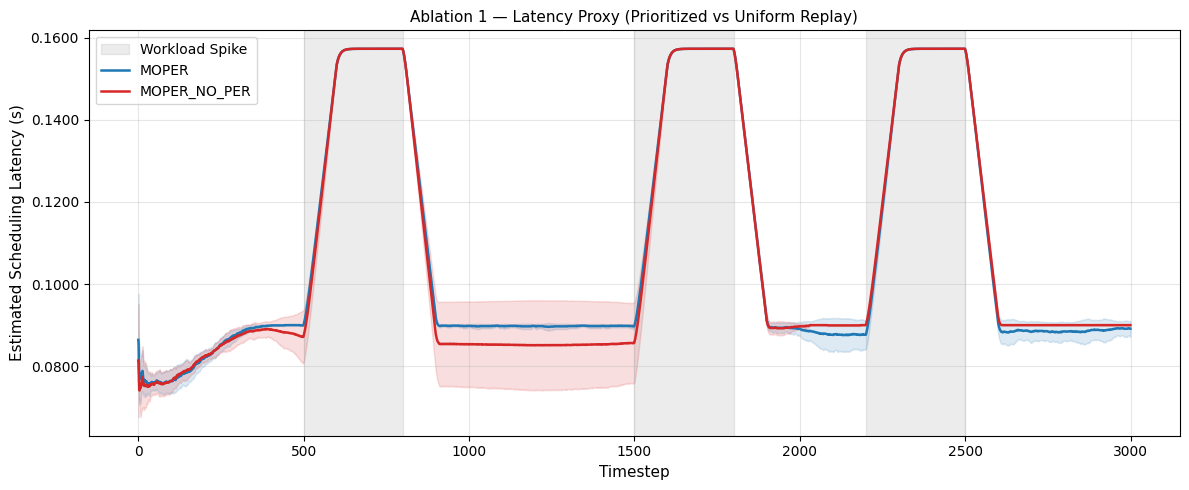

In [ ]:
# Cell 13 --- SECONDARY METRIC: Estimated Scheduling Latency (REVISED)
# Applies to MOPER and MOPER_NO_PER under Ablation 1
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pathlib import Path

ABLATION1_BENCH_DIR = "results/ablation1/"

# Configuration
SMOOTH = 100  # Filters noise while preserving spike response shape

# CORRECTION: Removed S3 baselines, added ablated agent
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_PER': '#d62728'   # Red
}

# Spike boundaries for the repeated spike scenario
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION1_BENCH_DIR}/ablation1_benchmark_raw.csv")

# Handle column name variations
LATENCY_COL = 'selected_latency_s' if 'selected_latency_s' in df.columns else 'latency_s'

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty:
        print(f"Warning: No data found for {agent_name}")
        continue
        
    # Group by seed and timestep, calculate rolling mean/std across seeds
    pivot = sub.groupby(['seed', 'timestep'])[LATENCY_COL].mean().unstack(level='seed')
    smoothed = pivot.rolling(SMOOTH, min_periods=1)
    
    m = smoothed.mean().mean(axis=1)
    s = smoothed.mean().std(axis=1)
    
    display_label = agent_name
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=1.8)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('Estimated Scheduling Latency (s)', fontsize=11)

# Update title for Ablation 1 context
ax.set_title('Ablation 1 — Latency Proxy (Prioritized vs Uniform Replay)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper left')

ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.tight_layout()

# Save to directory with correct filename
Path(ABLATION1_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION1_BENCH_DIR}/ablation1_latency_secondary.png", dpi=150)
plt.show()

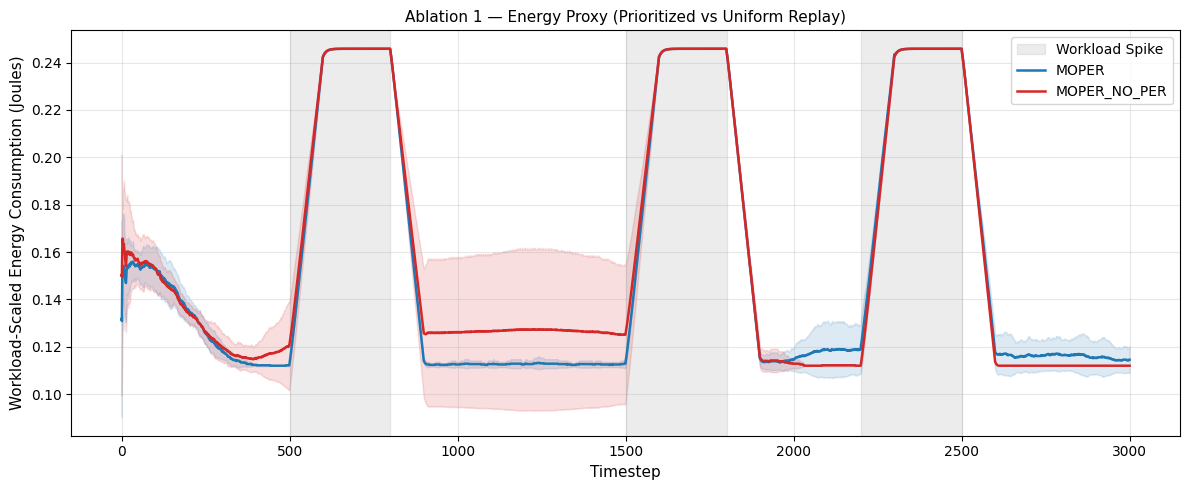

In [14]:
# Cell 14 --- SECONDARY METRIC: Workload-Scaled Energy Consumption (REVISED)
# Applies to MOPER and MOPER_NO_PER under Ablation 1
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION1_BENCH_DIR = "results/ablation1/"
SMOOTH = 100

# CORRECTION: Replaced S3 baselines with the ablated agent
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_PER': '#d62728'   # Red
}

SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION1_BENCH_DIR}/ablation1_benchmark_raw.csv")

# Handle potential column name variations
ENERGY_COL = 'selected_energy_j' if 'selected_energy_j' in df.columns else 'energy_j'

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # Group by seed and timestep, calculate rolling mean/std across seeds
    pivot = sub.groupby(['seed', 'timestep'])[ENERGY_COL].mean().unstack(level='seed')
    smoothed = pivot.rolling(SMOOTH, min_periods=1)
    
    m = smoothed.mean().mean(axis=1)
    s = smoothed.mean().std(axis=1)
    
    display_label = agent_name
    
    ax.plot(m.index, m.values, label=display_label, color=color, lw=1.8)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('Workload-Scaled Energy Consumption (Joules)', fontsize=11)

# CORRECTION: Update title for Ablation 1 context
ax.set_title('Ablation 1 — Energy Proxy (Prioritized vs Uniform Replay)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')

ax.grid(alpha=0.3)
plt.tight_layout()

# CORRECTION: Save to correct directory with correct ablation filename
Path(ABLATION1_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION1_BENCH_DIR}/ablation1_energy_secondary.png", dpi=150)
plt.show()

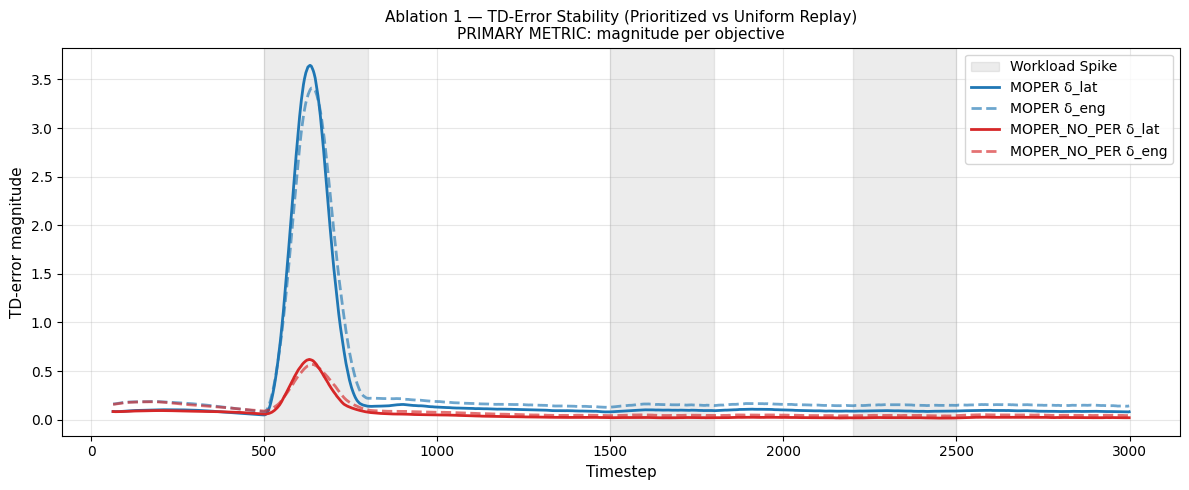

In [1]:
# Cell 15 --- PRIMARY METRIC: TD-Error Stability (Replay Bias Proof) (REVISED)
# Applies to MOPER and MOPER_NO_PER under Ablation 1
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION1_BENCH_DIR = "results/ablation1/"
SMOOTH = 100

# CORRECTION: Replaced S3 baselines with the ablated agent
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_PER': '#d62728'   # Red
}

SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the consolidated benchmark file for Ablation 1
df = pd.read_csv(f"{ABLATION1_BENCH_DIR}/ablation1_benchmark_raw.csv")

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # CORRECTION: Both MOPER and MOPER_NO_PER track dual td_lat and td_eng
    pivot_lat = sub.groupby(['seed', 'timestep'])['td_lat'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    pivot_eng = sub.groupby(['seed', 'timestep'])['td_eng'].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    
    ax.plot(pivot_lat.mean(axis=1), color=color, lw=2.0, label=f"{agent_name} δ_lat")
    ax.plot(pivot_eng.mean(axis=1), color=color, lw=2.0, ls="--", alpha=0.65, label=f"{agent_name} δ_eng")

ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('TD-error magnitude', fontsize=11)

# CORRECTION: Update title for Ablation 1 context
ax.set_title('Ablation 1 — TD-Error Stability (Prioritized vs Uniform Replay)\nPRIMARY METRIC: magnitude per objective', fontsize=11)

# Prevent duplicate legends from axvspan
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='upper right')

ax.grid(alpha=0.3)
plt.tight_layout()

# CORRECTION: Save to correct directory with correct ablation filename
Path(ABLATION1_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION1_BENCH_DIR}/ablation1_TDError_stability_primary.png", dpi=150)
plt.show()

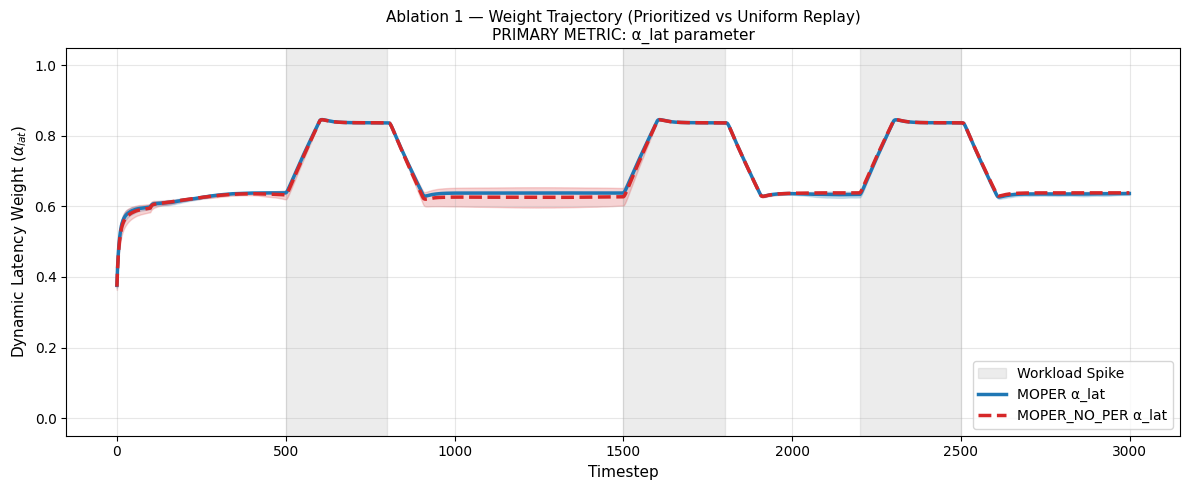

In [2]:
# Cell 16 --- PRIMARY METRIC: Weight Trajectory (α_lat) (REVISED)
# Applies to MOPER and MOPER_NO_PER under Ablation 1
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION1_BENCH_DIR = "results/ablation1/"
SMOOTH = 100

# CORRECTION: Target the ablated agent and full artifact
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_PER': '#d62728'   # Red
}

# CORRECTION: Replaced single spike with multi-spike boundaries
SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION1_BENCH_DIR}/ablation1_benchmark_raw.csv")

# Ensure canvas width matches previous cells (12, 5)
fig, ax = plt.subplots(figsize=(12, 5))

# Loop generates multiple grey bands for the back-to-back regime changes
for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # Handle potential column naming variations
    WEIGHT_COL = 'latency_weight' if 'latency_weight' in sub.columns else 'alpha_lat'
    
    pivot = sub.groupby(['seed', 'timestep'])[WEIGHT_COL].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    m = pivot.mean(axis=1)
    s = pivot.std(axis=1)
    
    # CORRECTION: Apply standard deviation bounds and distinct linestyles for both agents
    ls = "-" if agent_name == "MOPER" else "--"
    ax.plot(m.index, m.values, label=f"{agent_name} α_lat", color=color, lw=2.5, ls=ls)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel(r'Dynamic Latency Weight ($\alpha_{lat}$)', fontsize=11)

# CORRECTION: Update title for Ablation 1 context
ax.set_title('Ablation 1 — Weight Trajectory (Prioritized vs Uniform Replay)\nPRIMARY METRIC: α_lat parameter', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

# CORRECTION: Save to correct directory with correct ablation filename
Path(ABLATION1_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION1_BENCH_DIR}/ablation1_Weight_trajectory_latency_primary.png", dpi=150)
plt.show()

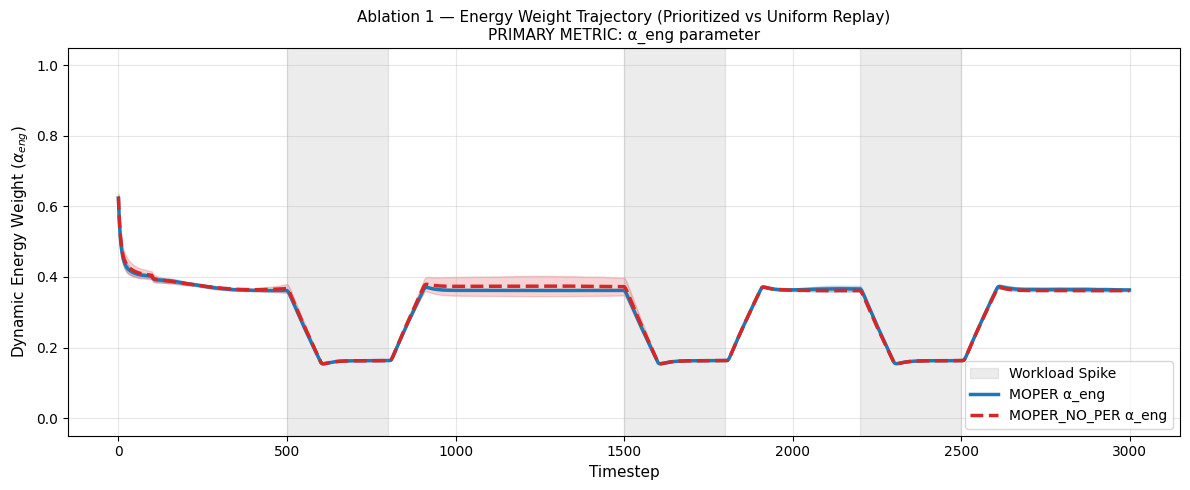

In [3]:
# Cell 17 --- PRIMARY METRIC: Weight Trajectory (α_eng) (REVISED)
# Applies to MOPER and MOPER_NO_PER under Ablation 1
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ABLATION1_BENCH_DIR = "results/ablation1/"
SMOOTH = 100

# CORRECTION: Target the ablated agent and full artifact
COLORS = {
    'MOPER': '#1f77b4',         # Blue
    'MOPER_NO_PER': '#d62728'   # Red
}

SPIKE_WINDOWS = [(500, 800), (1500, 1800), (2200, 2500)]

# CORRECTION: Load the Cell 12 consolidated benchmark file
df = pd.read_csv(f"{ABLATION1_BENCH_DIR}/ablation1_benchmark_raw.csv")

fig, ax = plt.subplots(figsize=(12, 5))

for i, (start, end) in enumerate(SPIKE_WINDOWS):
    label = 'Workload Spike' if i == 0 else None
    ax.axvspan(start, end, color='gray', alpha=0.15, label=label)

for agent_name, color in COLORS.items():
    sub = df[df['agent'].str.upper() == agent_name.upper()].copy()
    if sub.empty: 
        print(f"Warning: No data found for {agent_name}")
        continue
    
    # Handle potential column naming variations
    WEIGHT_COL = 'energy_weight' if 'energy_weight' in sub.columns else 'alpha_eng'
    
    pivot = sub.groupby(['seed', 'timestep'])[WEIGHT_COL].mean().unstack(level='seed').rolling(SMOOTH, min_periods=1).mean()
    m = pivot.mean(axis=1)
    s = pivot.std(axis=1)
    
    # CORRECTION: Apply standard deviation bounds and distinct linestyles for both agents
    ls = "-" if agent_name == "MOPER" else "--"
    ax.plot(m.index, m.values, label=f"{agent_name} α_eng", color=color, lw=2.5, ls=ls)
    ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel(r'Dynamic Energy Weight ($\alpha_{eng}$)', fontsize=11)

# CORRECTION: Update title for Ablation 1 context
ax.set_title('Ablation 1 — Energy Weight Trajectory (Prioritized vs Uniform Replay)\nPRIMARY METRIC: α_eng parameter', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()

# CORRECTION: Save to correct directory with correct ablation filename
Path(ABLATION1_BENCH_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{ABLATION1_BENCH_DIR}/ablation1_Weight_trajectory_energy_primary.png", dpi=150)
plt.show()